# Real SageMaker Multi-Turn RL: train, evaluate, deploy, compare

Everything in this notebook runs on **real AWS resources** (account `384887233198`, region `us-west-2`) and follows the official guide:
[Multi-turn reinforcement learning in SageMaker AI](https://docs.aws.amazon.com/sagemaker/latest/dg/model-customize-mtrl.html).

| Step | Official API | What you will see |
|---|---|---|
| Baseline | `MultiTurnRLEvaluator(model="openai-reasoning-gpt-oss-20b")` | How the untrained model performs |
| Train | `MultiTurnRLTrainer(...).train()` → `job.wait()` | A real MTRL job producing a LoRA adapter |
| Evaluate | `MultiTurnRLEvaluator(model=job, evaluate_base_model=True)` | Base vs fine-tuned, same prompts |
| Inference (recorded) | MLflow traces of that evaluation | Real conversations of both models, side by side |
| Deploy | `ModelBuilder(model=ModelPackage).build()` → `deploy()` | One endpoint: base model + LoRA adapter |
| Inference (live) | `endpoint.invoke(...)` plus the agent | The same tickets on the live endpoint, when GPU capacity allows |

See [HOW_IT_WORKS.md](HOW_IT_WORKS.md) for diagrams of every step.

**Run modes.** By default the notebook is in *replay* mode: it re-attaches to the recorded jobs and shows their real results, and submits nothing. A billable step runs only when its exact confirmation phrase is supplied through an environment variable (`MTRL_TRAIN_CONFIRMATION`, `MTRL_COMPARISON_CONFIRMATION`, `MTRL_DEPLOY_CONFIRMATION`). A recorded job is always re-attached, never submitted twice. Select the **Python 3.12 (AWS MTRL)** kernel.

**Before deploying** (section 8), start the safety watchdog in a terminal: `.venv-aws/bin/python aws/endpoint_watchdog.py`. Deployment refuses to start without it. **After executing**, remove the temporary MLflow sign-in links the SDK prints: `.venv-aws/bin/python aws/evidence.py <executed notebook>`.

In [1]:
import logging
import os
import sys
from pathlib import Path

for noisy in ("sagemaker", "botocore", "boto3", "urllib3", "httpx", "mlflow"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

ROOT = Path.cwd()
for folder in ("aws", "agent"):
    if str(ROOT / folder) not in sys.path:
        sys.path.insert(0, str(ROOT / folder))

from config import DemoConfig

# Pin every AWS client to the demo region before boto3 or the SDK load.
os.environ["AWS_DEFAULT_REGION"] = os.environ["AWS_REGION"] = DemoConfig().region

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from workflow import MtrlDemoWorkflow

workflow = MtrlDemoWorkflow()
config = workflow.config

TRAIN_CONFIRMATION = os.environ.get("MTRL_TRAIN_CONFIRMATION", "")
COMPARISON_CONFIRMATION = os.environ.get("MTRL_COMPARISON_CONFIRMATION", "")
DEPLOY_CONFIRMATION = os.environ.get("MTRL_DEPLOY_CONFIRMATION", "")
BEDROCK_IMPORT_CONFIRMATION = os.environ.get("MTRL_BEDROCK_IMPORT_CONFIRMATION", "")
LIVE_INFERENCE = os.environ.get("MTRL_LIVE_INFERENCE") == "1"

KEY_METRICS = {
    "eval/reward/pass_at_1": "Ticket fully solved (pass@1)",
    "eval/reward/pass_at_2": "Solved in 1 of 2 tries (pass@2)",
    "eval/reward/mean": "Mean reward (with partial credit)",
    "eval/reward/succeeded_rollouts": "Rollouts fully solved",
    "eval/reward/failed_rollouts": "Rollouts not fully solved",
    "eval/turns/mean": "Model calls per rollout",
}
billable = [p for p in (TRAIN_CONFIRMATION, COMPARISON_CONFIRMATION, DEPLOY_CONFIRMATION,
                         BEDROCK_IMPORT_CONFIRMATION) if p] + (["live inference"] if LIVE_INFERENCE else [])
print("Mode:", "RUN (confirmed billable steps may execute)" if billable else "REPLAY (no new jobs)")

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/ishamrashik/Library/Application Support/sagemaker/config.yaml


Mode: RUN (confirmed billable steps may execute)


## 1. Verify the real AWS setup

Caller identity, region, supported model, the deployed AgentCore runtime (our support agent), the MLflow app, and both prompt sets.

In [2]:
validation = workflow.validate()
for name, value in validation.items():
    print(f"{name:20s} {value}")

account_id           384887233198
caller_arn           arn:aws:iam::384887233198:user/mlflow
region               us-west-2
model                openai-reasoning-gpt-oss-20b
agent_runtime_arn    arn:aws:bedrock-agentcore:us-west-2:384887233198:runtime/mtrl_support_agent-OAXxBY5ULs
training_prompts     64
evaluation_prompts   32
mlflow_app_arn       arn:aws:sagemaker:us-west-2:384887233198:mlflow-app/app-N7OYBKIHZSQR


## 2. Prompt datasets

64 training tickets and 32 **held-out** evaluation tickets (never used for training). SageMaker requires more training prompts than the batch size (32). Uploading is idempotent: unchanged files are not re-uploaded.

In [3]:
uploads = workflow.upload_datasets()
for split, info in uploads.items():
    action = "uploaded" if info["uploaded"] else "unchanged, existing S3 object kept"
    print(f"{split:10s} {info['uri']}  ->  {action}")

prompts = pd.read_csv(ROOT / "data/training_prompts.csv")
print(f"\n{len(prompts)} training tickets, for example:")
for text in prompts["prompt"].head(3):
    print("  -", text)

training   s3://sagemaker-mtrl-demo-384887233198-us-west-2/datasets/training_prompts.parquet  ->  unchanged, existing S3 object kept
evaluation s3://sagemaker-mtrl-demo-384887233198-us-west-2/datasets/evaluation_prompts.parquet  ->  unchanged, existing S3 object kept

64 training tickets, for example:
  - Resolve the customer's internet outage. Customer says: My internet is not working.
  - Resolve the customer's internet outage. Customer says: I am connected to Wi-Fi but cannot reach the internet.
  - Resolve the customer's internet outage. Customer says: My router's WAN light is red.


## 3. Budget check (hard cap: $25)

Spent amounts are the token counts AWS actually billed (`BillableTokenUsage`). Planned amounts scale this account's measured per-rollout usage with a 1.5x safety margin, plus the endpoint's maximum lifetime at the official hourly price. The guard refuses any plan above the cap.

In [4]:
from cost_guard import MtrlCostGuard

ledger = workflow.ledger()
guard = MtrlCostGuard.from_price_list(config)
budget = guard.evaluate(ledger.measured_reference(), ledger.spent(), ledger.remaining())
display(pd.DataFrame(budget["lines"]).rename(columns={"item": "Cost item", "usd": "USD"}))
print(f"Projected total: ${budget['projected_total_usd']:.2f} of the hard ${budget['budget_cap_usd']} cap")

,Cost item,USD
0,Base evaluation (first attempt),0.0069
1,Base evaluation,0.0341
2,Training,2.8296
3,Comparison: base model,0.0355
4,Comparison: fine-tuned model,0.0362
5,Cross-region copy of weights to us-east-1 (41....,0.8400
6,Bedrock imported model inference (estimate: 1 ...,2.0000
7,Endpoint uptime,0.0000
8,"Contingency (AgentCore, CodeBuild, S3, logs)",2.0000


Projected total: $7.78 of the hard $25 cap


## 4. The task the agent must learn

A customer reports that their internet is down. The agent (GPT-OSS-20B inside a Strands agent on Bedrock AgentCore) has **4 turns**. Each turn it picks one action through a tool. Only one action per situation moves the diagnosis forward. Each correct step earns 0.25; restoring the connection earns 1.0. One wrong action wastes a turn, so the episode ends one step short.

In [5]:
from environment import ACTIONS, MAX_PROGRESS, SUCCESS_PATH, TRANSITIONS

rows = []
for step, state in enumerate(SUCCESS_PATH[:-1], start=1):
    correct = next(action for (source, action) in TRANSITIONS if source == state)
    rows.append({
        "Turn": step,
        "Situation": state,
        "Correct action": correct,
        "Tempting alternatives": ", ".join(a for a in ACTIONS[state] if a != correct),
        "Reward after this step": step / MAX_PROGRESS,
    })
display(pd.DataFrame(rows))

,Turn,Situation,Correct action,Tempting alternatives,Reward after this step
0,1,new_ticket,check_outage,"restart_router, close_ticket",0.25
1,2,no_outage,inspect_router_lights,"restart_router, close_ticket",0.50
2,3,red_wan_light,check_account_config,"replace_router, close_ticket",0.75
3,4,config_mismatch,apply_config_fix,"escalate, close_ticket",1.00


## 5. Baseline: the base model before training

A real SageMaker evaluation of the untrained GPT-OSS-20B through our agent: 32 held-out tickets, 2 attempts each. The usual mistake is the shortcut `restart_router`, which wastes a turn.

In [6]:
baseline = workflow.base_evaluation_evidence()
base_metrics = baseline["metrics"]
print("SageMaker pipeline execution:", baseline["execution"]["arn"])
display(pd.DataFrame(
    [{"Metric": label, "Base model": base_metrics[key]} for key, label in KEY_METRICS.items()]
))

SageMaker pipeline execution: arn:aws:sagemaker:us-west-2:384887233198:pipeline/SagemakerEvaluation-MTRLEvaluation/execution/7kz12i8e43ip


,Metric,Base model
0,Ticket fully solved (pass@1),0.50000
1,Solved in 1 of 2 tries (pass@2),0.84375
2,Mean reward (with partial credit),0.87500
3,Rollouts fully solved,32.00000
4,Rollouts not fully solved,32.00000
5,Model calls per rollout,5.84375


## 6. Training: `MultiTurnRLTrainer` (official guide)

Approved size: **10 training steps**, each on **32 tickets x 4 rollouts** (1,280 rollouts in total). The job runs our agent on AgentCore for every rollout, scores each full conversation with the environment's reward, and updates a LoRA adapter on GPT-OSS-20B.

In [7]:
training = workflow.training_stage()
trainer = training.build_trainer()
hp = trainer.hyperparameters
display(pd.DataFrame([
    ("Base model", trainer.model),
    ("Agent environment (AgentCore runtime)", trainer.agent_env),
    ("Training prompts", trainer.training_dataset),
    ("Training steps", hp.max_steps),
    ("Rollouts per prompt (group size)", hp.group_size),
    ("Global batch size", hp.global_batch_size),
    ("Learning rate", hp.learning_rate),
    ("LoRA rank / alpha", f"{hp.lora_rank} / {hp.lora_alpha}"),
    ("Policy loss", hp.loss_fn),
], columns=["Setting", "Value"]))

,Setting,Value
0,Base model,openai-reasoning-gpt-oss-20b
1,Agent environment (AgentCore runtime),arn:aws:bedrock-agentcore:us-west-2:3848872331...
2,Training prompts,s3://sagemaker-mtrl-demo-384887233198-us-west-...
3,Training steps,10
4,Rollouts per prompt (group size),4
5,Global batch size,32
6,Learning rate,0.00001
7,LoRA rank / alpha,32 / 64
8,Policy loss,ppo


In [8]:
job = training.run_or_attach(TRAIN_CONFIRMATION)
if job is None:
    print("No training job recorded yet. Set MTRL_TRAIN_CONFIRMATION to submit one.")
else:
    print("Training job:", job.job_name)
    print("Status:      ", job.job_status)

Training job: openai-reasoning-gpt-oss-20b-mtrl-20261002040558
Status:       Completed


In [9]:
if job is not None:
    job = training.wait(job, timeout_seconds=4 * 3600)
    summary = training.summary(job)
    display(pd.DataFrame([
        ("Job", summary["job_name"]),
        ("Status", summary["job_status"]),
        ("Failure reason", summary["failure_reason"]),
        ("Duration (minutes)", summary["duration_minutes"]),
        ("Trained LoRA adapter (model package)", summary["output_model_package_arn"]),
        ("Billed tokens", summary["billable_token_usage"]),
    ], columns=["Field", "Value"]))

,Field,Value
0,Job,openai-reasoning-gpt-oss-20b-mtrl-20261002040558
1,Status,Completed
2,Failure reason,
3,Duration (minutes),19.2
4,Trained LoRA adapter (model package),arn:aws:sagemaker:us-west-2:384887233198:model...
5,Billed tokens,"{'PrefillTokenCount': 4833702, 'SampleTokenCou..."


/Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/10/02 09:33:37 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.



------------------------------------------------------------------------------------------------------------------
  Training Metrics
------------------------------------------------------------------------------------------------------------------
  Step                Reward/Mean                 Turns/Mean      Training/Total Tokens  Training/Num Trajectories
------------------------------------------------------------------------------------------------------------------
     1                     0.8887                     6.4844                     534113                        128
     2                     0.8906                     6.7969                     571359                        128
     3                     0.9102                     6.8438                     575191                        128
     4                     0.9277                     6.6328                     548452                        128
     5                     0.9219                     6.6250

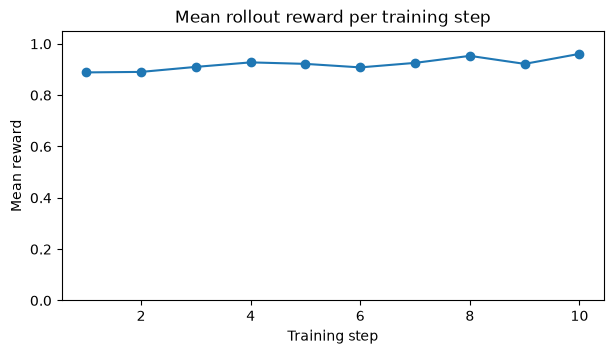

In [10]:
if job is not None and job.job_status == "Completed":
    steps = pd.DataFrame(job.get_training_metrics())
    if steps.empty:
        print("MLflow has no per-step metrics for this job yet.")
    else:
        ax = steps.plot(x="step", y="rollout/reward/mean", marker="o", legend=False, figsize=(7, 3.5))
        ax.set(title="Mean rollout reward per training step", xlabel="Training step",
               ylabel="Mean reward", ylim=(0, 1.05))
        plt.show()

## 7. Evaluation: base vs fine-tuned (official guide)

One `MultiTurnRLEvaluator(model=job, evaluate_base_model=True)` pipeline evaluates both models on the same 32 held-out tickets. Each model's metrics come from its own MLflow run.

In [11]:
evaluation = workflow.evaluation_stage()
trained_job = job if job is not None and job.job_status == "Completed" else None
execution_arn = evaluation.run_or_attach(COMPARISON_CONFIRMATION, trained_job)
status = None
if execution_arn is None:
    print("No comparison recorded yet. Set MTRL_COMPARISON_CONFIRMATION to run it.")
else:
    print("Comparison pipeline:", execution_arn)
    status = evaluation.wait(execution_arn, timeout_seconds=2 * 3600)

Comparison pipeline: arn:aws:sagemaker:us-west-2:384887233198:pipeline/SagemakerEvaluation-MTRLEvaluation/execution/8hvze02od4o0


  09:33:42  CreateEvaluationAction: Succeeded


  09:33:42  EvaluateBaseModel: Succeeded


  09:33:42  EvaluateFineTunedModel: Succeeded


  09:33:42  AssociateLineage: Succeeded


Pipeline Succeeded.


,Metric,Base model,Fine-tuned model
0,Ticket fully solved (pass@1),0.578125,0.781250
1,Solved in 1 of 2 tries (pass@2),0.812500,0.937500
2,Mean reward (with partial credit),0.882812,0.925781
3,Rollouts fully solved,37.000000,50.000000
4,Rollouts not fully solved,27.000000,14.000000
5,Model calls per rollout,6.093750,6.453125


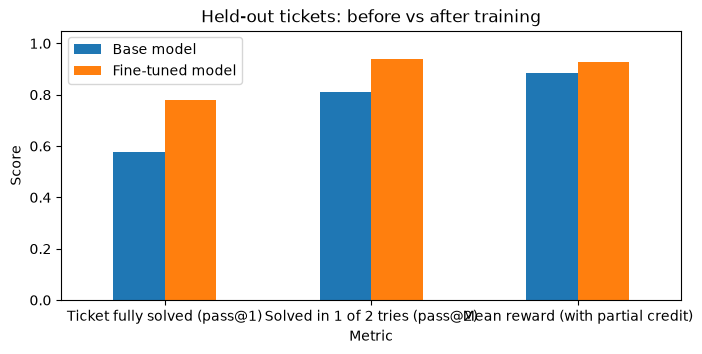

Note: 64 rollouts per model, so differences under about 0.1 are within sampling noise.


In [12]:
if status == "Succeeded":
    results = evaluation.results(execution_arn)
    comparison = pd.DataFrame([
        {"Metric": label,
         "Base model": results["base"]["metrics"].get(key),
         "Fine-tuned model": results["fine_tuned"]["metrics"].get(key)}
        for key, label in KEY_METRICS.items()
    ])
    display(comparison)
    chart = comparison.set_index("Metric").loc[[KEY_METRICS[k] for k in (
        "eval/reward/pass_at_1", "eval/reward/pass_at_2", "eval/reward/mean")]]
    ax = chart.plot.bar(figsize=(8, 3.5), rot=0, ylim=(0, 1.05))
    ax.set(title="Held-out tickets: before vs after training", ylabel="Score")
    plt.show()
    print("Note: 64 rollouts per model, so differences under about 0.1 are within sampling noise.")

## 8. Inference before vs after training, recorded by SageMaker

During the evaluation above, SageMaker ran **both models through the same agent on the same held-out tickets** and stored every conversation as an MLflow trace: the ticket, the model's reasoning, each tool call, and the reward. These are real inference results for the base and the fine-tuned model, from the same pipeline and the same serving stack, so no endpoint is needed to show them.

In [13]:
from inference import side_by_side
from trajectories import TrajectoryReader, compare_tickets, pair_by_ticket

recorded = workflow.store.load(TrajectoryReader.RECORD)
if recorded is None and status == "Succeeded":
    reader = TrajectoryReader.create(workflow.session, workflow.state.mlflow_app_arn)
    before = reader.read_run(results["base"]["run_id"])
    after = reader.read_run(results["fine_tuned"]["run_id"])
    order = pd.read_csv(ROOT / "data/evaluation_prompts.csv")["prompt"].tolist()
    pairs = pair_by_ticket(before, after, order)
    recorded = {"pairs": pairs, "summary": compare_tickets(pairs)}
    workflow.store.save(TrajectoryReader.RECORD, recorded)
if recorded:
    summary = recorded["summary"]
    print(f"Held-out tickets: {len(recorded['pairs'])} (2 tries per model each)")
    print(f"Fine-tuned model scored higher on {summary['improved']}, the same on {summary['same']}, "
          f"lower on {summary['worse']} (mean reward per ticket)")

Held-out tickets: 32 (2 tries per model each)
Fine-tuned model scored higher on 13, the same on 13, lower on 6 (mean reward per ticket)


In [14]:
LABELS = {"before": "Before training (base model)", "after": "After training (fine-tuned)"}


def show_conversation(pair, attempt=0):
    entry = {key: {"reward": pair[key][attempt]["reward"], "trace": pair[key][attempt]["steps"]}
             for key in ("before", "after")}
    print()
    print("Ticket:", pair["ticket"].split("Customer says: ")[-1])
    for key in ("before", "after"):
        thought = " ".join(pair[key][attempt]["first_thought"].split())[:220]
        print(f"  {LABELS[key]} first thought: {thought}")
    display(pd.DataFrame(side_by_side(entry, LABELS)).set_index("Turn"))


if recorded:
    print("The first three held-out tickets in dataset order (attempt 1 of 2 for each model):")
    for pair in recorded["pairs"][:3]:
        show_conversation(pair)
    changed = next((pair for pair in recorded["pairs"][3:]
                    if pair["before"][0]["reward"] < 1.0 <= pair["after"][0]["reward"]), None)
    if changed:
        print()
        print("A selected example where training changed the outcome:")
        show_conversation(changed)

The first three held-out tickets in dataset order (attempt 1 of 2 for each model):

Ticket: My Wi-Fi works, but websites do not load.
  Before training (base model) first thought: We need to choose an action. The customer says Wi-Fi works but websites do not load. That suggests DNS or routing issue. We can check outage or restart router. The first step: check_outage.
  After training (fine-tuned) first thought: We need to choose an action. The customer says Wi-Fi works but websites do not load. That suggests DNS or routing issue. We have actions: restart_router, close_ticket, check_outage. We should check for outage first. So c


,Before training (base model),After training (fine-tuned)
Turn,,
1,check_outage [correct],check_outage [correct]
2,inspect_router_lights [correct],inspect_router_lights [correct]
3,check_account_config [correct],check_account_config [correct]
4,apply_config_fix [correct],apply_config_fix [correct]
Reward,1.0,1.0



Ticket: The internet light changed from green to red.
  Before training (base model) first thought: We need to use take_support_action tool. First action: check_outage.
  After training (fine-tuned) first thought: We need to choose an action. The first step: check_outage.


,Before training (base model),After training (fine-tuned)
Turn,,
1,check_outage [correct],check_outage [correct]
2,inspect_router_lights [correct],inspect_router_lights [correct]
3,check_account_config [correct],check_account_config [correct]
4,apply_config_fix [correct],apply_config_fix [correct]
Reward,1.0,1.0



Ticket: My service stopped working after a plan change.
  Before training (base model) first thought: We need to use take_support_action tool. First action: check_outage.
  After training (fine-tuned) first thought: We need to choose an action. The customer says service stopped after plan change. We have actions: restart_router, close_ticket, check_outage. Likely check_outage first.


,Before training (base model),After training (fine-tuned)
Turn,,
1,check_outage [correct],check_outage [correct]
2,restart_router [wasted turn],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0



A selected example where training changed the outcome:

Ticket: Every browser reports that I am offline.
  Before training (base model) first thought: We need to choose an action. The first step: likely restart_router. Use tool.
  After training (fine-tuned) first thought: We need to choose an action. The first step: check outage.


,Before training (base model),After training (fine-tuned)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0


## 9. Deploy option 1: SageMaker real-time endpoint (official guide)

`ModelPackage.get(...)` → `ModelBuilder(model=package).build()` → `deploy(...)`. For this training output, SageMaker serves the **fine-tuned model**: the trained LoRA adapter merged into GPT-OSS-20B, in one inference component on `ml.g6e.12xlarge` (4 x NVIDIA L40S, about $13 per hour).

`deploy()` first checks the AWS account, the watchdog heartbeat, the $25 budget, and the endpoint quota. The endpoint role also needs permission to pull the AWS inference container (`aws/hosting_access.py`, granted once). The endpoint is deleted at the end of this notebook, and the watchdog deletes it after 60 minutes at the latest.

In [15]:
deployment = workflow.deployment_stage(hourly_usd=guard.hosting_hourly_usd)
model_package_arn = job.output_model_package_arn if job is not None else None
endpoint = None
try:
    budget = guard.evaluate(ledger.measured_reference(), ledger.spent(), ledger.remaining())
    print(f"Projected total spend: ${budget['projected_total_usd']:.2f} "
          f"of the hard ${budget['budget_cap_usd']} cap")
    endpoint = deployment.deploy(DEPLOY_CONFIRMATION, model_package_arn)
except Exception as error:
    print(f"Deployment did not complete: {type(error).__name__}: {str(error)[:400]}")
    endpoint = workflow.store.load("endpoint.json")
if endpoint is None:
    print("No endpoint recorded yet. Set MTRL_DEPLOY_CONFIRMATION to deploy.")

Projected total spend: $7.78 of the hard $25 cap


In [16]:
live = endpoint is not None and endpoint.get("endpoint_status") == "InService"
if endpoint is not None:
    print("Endpoint:     ", endpoint["endpoint_name"])
    print("Status:       ", endpoint.get("endpoint_status") or endpoint.get("status"))
    print("Instance type:", endpoint["instance_type"])
    print("Model package:", model_package_arn)
    if endpoint.get("failure_reason"):
        print("Outcome:      ", endpoint["failure_reason"][:400])
    if endpoint.get("billing_note"):
        print("Billing:      ", endpoint["billing_note"])
    if endpoint.get("components"):
        display(pd.DataFrame(endpoint["components"])[["name", "role", "status", "base_component"]])

Endpoint:      mtrl-support-demo
Status:        Deleted
Instance type: ml.g6e.12xlarge
Model package: arn:aws:sagemaker:us-west-2:384887233198:model-package/openai-reasoning-gpt-oss-20b-mtrl-mpg/1
Outcome:       FailedStatusError: Encountered unexpected failed state while waiting for Endpoint. Final Resource State: Failed. Failure Reason: Unable to provision requested ML compute capacity due to InsufficientInstanceCapacity error. Please retry using a different ML instance type or after some time. Consider configuring InstancePools in your EndpointConfig with multiple instance types for priority-based fall
Billing:       Endpoint never reached InService (InsufficientInstanceCapacity); no instance was billed. Earlier value 8.39 assumed billing from creation.


## 10. Deploy option 2: import into Amazon Bedrock (official guide)

The guide's second deployment option imports the trained model into **Amazon Bedrock Custom Model Import**. It is serverless: no GPU instance to provision, no endpoint quota, billed per active minute, and scaled to zero when idle.

GPT-OSS imports run only in **us-east-1**, so the merged fine-tuned weights are copied there first. Two files are fixed in that copy, exactly as the Bedrock documentation requires for GPT-OSS: the chat template goes into `tokenizer_config.json`, and `generation_config.json` gets all three end-of-sequence token IDs. The training output itself is not changed.

In [17]:
from bedrock_import import BedrockImporter, merged_weights_uri

importer = BedrockImporter(config, workflow.state, workflow.store, workflow.session)
bedrock_record = workflow.store.load(BedrockImporter.RECORD)
if bedrock_record is None and BEDROCK_IMPORT_CONFIRMATION == "CONFIRM_BEDROCK_IMPORT_MTRL_DEMO" and job is not None:
    source = merged_weights_uri(workflow.session.client("sagemaker"), job.output_model_package_arn)
    importer.prepare_artifacts(source)
    importer.start(importer.ensure_role())
    bedrock_record = importer.wait(timeout_seconds=3 * 3600)
bedrock_ready = bool(bedrock_record) and bedrock_record.get("status") == "Completed"
if bedrock_record:
    print("Import job:     ", bedrock_record["job_name"])
    print("Status:         ", bedrock_record.get("status"))
    print("Model files:    ", bedrock_record["source_uri"])
    if bedrock_record.get("failure_message"):
        print("Failure:        ", bedrock_record["failure_message"][:400])
    if bedrock_ready:
        details = importer.describe()
        print("Imported model: ", details["modelArn"])
        print("Architecture:   ", details["modelArchitecture"])
else:
    print("Not imported yet. Set MTRL_BEDROCK_IMPORT_CONFIRMATION to import.")

Import job:      mtrl-support-import-20261002051532
Status:          Completed
Model files:     s3://sagemaker-mtrl-demo-384887233198-us-east-1/imported-models/mtrl-support-gpt-oss-20b-ft/


Imported model:  arn:aws:bedrock:us-east-1:384887233198:imported-model/ffakmfmpoqbi
Architecture:    oss


## 11. Live inference: the same tickets, before vs after training

The **same support agent** used in training (`SupportRolloutAgent.run_episode`: same prompt, tool, and environment) runs held-out tickets with both models, using the same action order:

- **Before training**: base GPT-OSS-20B on Amazon Bedrock, the same open weights training started from
- **After training**: the fine-tuned model, on the SageMaker endpoint if it is running, otherwise the Bedrock imported model

Live calls run only with `MTRL_LIVE_INFERENCE=1`. Otherwise the notebook shows the saved results of the last live run.

In [18]:
from bedrock_import import IMPORT_REGION, chat_with_imported_model, imported_model
from inference import bedrock_base_model, endpoint_model, side_by_side

after = None
if live:
    names = deployment.component_names()
    after = ("After training: fine-tuned model (SageMaker endpoint)",
             endpoint_model(config, names["fine_tuned"], workflow.session))
elif bedrock_ready:
    after = ("After training: fine-tuned model (Bedrock Custom Model Import)",
             imported_model(config, bedrock_record["imported_model_arn"], workflow.session))

QUESTION = "My internet is not working. What is the first troubleshooting step?"
if LIVE_INFERENCE and after is not None:
    if live:
        reply = workflow.inference().chat(names["fine_tuned"], QUESTION)
    else:
        runtime = workflow.session.client("bedrock-runtime", region_name=IMPORT_REGION)
        reply = chat_with_imported_model(runtime, bedrock_record["imported_model_arn"], QUESTION,
                                         config.sampling_max_tokens)
        workflow.store.save("inference_chat.json", {"component": after[0], "message": QUESTION, "reply": reply})
else:
    reply = (workflow.store.load("inference_chat.json") or {}).get("reply")
if reply:
    print("Question:", QUESTION)
    print()
    print("Fine-tuned model reply:")
    print(reply.strip()[:800])
else:
    print("No live inference recorded yet. Set MTRL_LIVE_INFERENCE=1 once a deployment is ready.")

Question: My internet is not working. What is the first troubleshooting step?

Fine-tuned model reply:
**First troubleshooting step:**  
Check that your device is actually connected to your network *and* that the network hardware (modem/router) is showing a healthy “Internet” signal.  

1. **Verify the device’s connection**  
   - If you’re on Wi‑Fi: make sure the icon shows you’re connected to the right SSID.  
   - If you’re on a wired ethernet


In [19]:
if LIVE_INFERENCE and after is not None:
    tickets = pd.read_csv(ROOT / "data/evaluation_prompts.csv")["prompt"].head(6).tolist()
    models = {"before": ("Before training: base GPT-OSS-20B (Amazon Bedrock)",
                         bedrock_base_model(config, workflow.session)),
              "after": after}
    inference_results = workflow.inference().compare(models, tickets, seed=2026)
else:
    inference_results = workflow.store.load("inference_before_after.json")
if inference_results:
    labels = inference_results["labels"]
    total = len(inference_results["tickets"])
    for key in ("before", "after"):
        solved = sum(1 for e in inference_results["tickets"] if e[key].get("reward") == 1.0)
        print(f"{labels[key]}: {solved} of {total} tickets fully solved")
    for entry in inference_results["tickets"]:
        print()
        print("Ticket:", entry["ticket"].split("Customer says: ")[-1])
        display(pd.DataFrame(side_by_side(entry, labels)).set_index("Turn"))

[10/02/26 09:33:50] INFO     Creating Strands MetricsClient                                          ]8;id=6552289;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/strands/telemetry/metrics.py\metrics.py]8;;\:]8;id=6552290;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/strands/telemetry/metrics.py#632\632]8;;\

[10/02/26 09:33:57] INFO     payload=<{                                                            ]8;id=6552297;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/strands/models/sagemaker.py\sagemaker.py]8;;\:]8;id=6552298;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/strands/models/sagemaker.py#353\353]8;;\
                               "messages": [                                                                       
                                 {                                                                                 
                                   "role": "system",                                                               
                                   "content": "You are a customer-support troubleshooting                          
                             agent.\nYour objective is to restore the customer's internet                          
                             connection.\n\nRules:\n- Use the take_support_action tool exactly                     
                             once for each decision.\n- Choose only an action listed in                            
                             available_actions.\n- Use each tool result as the next                                
                             observation.\n- Continue until terminal=true or no turns remain.\n-                   
                             Do not invent tool results or claim success unless the tool reports                   
                             it.\n- If you cannot call the tool, reply with only the chosen action                 
                             name.\n- Keep text responses brief because success is measured by the                 
                             environment.\n"                                                                       
                                 },                                                                                
                                 {                                                                                 
                                   "role": "user",                                                                 
                                   "content": [                                                                    
                                     {                                                                             
                                       "text": "Resolve the customer's internet outage. Customer                   
                             says: My Wi-Fi works, but websites do not load.\n\nInitial                            
                             environment:\n{\"state\": \"new_ticket\", \"observation\": \"The                      
                             customer reports that their internet is not working.\",                               
                             \"available_actions\": [\"restart_router\", \"check_outage\",                         
                             \"close_ticket\"], \"turns_remaining\": 4}\nBegin troubleshooting                     
                             using the tool.",                                                                     
                                       "type": "text"                                                              
                                     }                                                                             
                                   ]                                                                               
                                 }                                                                                 
                               ],                                                                                  
                               "tools": [   

[10/02/26 09:33:58] INFO     response=<{                                                           ]8;id=6552304;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/strands/models/sagemaker.py\sagemaker.py]8;;\:]8;id=6552305;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/strands/models/sagemaker.py#518\518]8;;\
                               "id": "chatcmpl-a5f992020ddb46d2",                                                  
                               "object": "chat.completion",                                                        
                               "created": 1790919237,                                                              
                               "model": "384887233198-ffakmfmpoqbi",                                               
                               "choices": [                                                                        
                                 {                                                                                 
                                   "index": 0,                                                                     
                                   "message": {                                                                    
                                     "role": "assistant",                                                          
                                     "content": "{\"action\":\"check_outage\"}",                                   
                                     "refusal": null,                                                              
                                     "annotations": null,                                                          
                                     "audio": null,                                                                
                                     "function_call": null,                                                        
                                     "tool_calls": [],                                                             
                                     "reasoning": "We need to resolve issue: Wi-Fi works but                       
                             websites do not load. The customer likely has DNS issue or new IP.                    
                             The actions: restart_router, check_outage, close_ticket. We need to                   
                             choose action. Usually DNS issue, but we can't config; maybe check                    
                             outage to see if local internet is down. But wifi works - maybe local                 
                             network fine but ISP has issues. Let's check outage first.\n\nSo call                 
                             take_support_action \"check_outage\".",                                               
                                     "reasoning_content": "We need to resolve issue: Wi-Fi works                   
                             but websites do not load. The customer likely has DNS issue or new                    
                             IP. The actions: restart_router, check_outage, close_ticket. We need                  
                             to choose action. Usually DNS issue, but we can't config; maybe check                 
                             outage to see if local internet is down. But wifi works - maybe local                 
                             network fine but ISP has issues. Let's check outage first.\n\nSo call                 
                             take_support_action \"check_outage\"."                                                
                                   },                                                                              
                                   "logprobs

                    INFO     Recovered text-only action: check_outage                         ]8;id=6552312;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/agent/rollout_driver.py\rollout_driver.py]8;;\:]8;id=6552313;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/agent/rollout_driver.py#177\177]8;;\

                    WARNING  reasoningContent is not supported in multi-turn conversations with the   ]8;id=6552320;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/strands/models/openai.py\openai.py]8;;\:]8;id=6552321;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/strands/models/openai.py#412\412]8;;\
                             Chat Completions API.                                                                 

...

,Before training: base GPT-OSS-20B (Amazon Bedrock),After training: fine-tuned model (Bedrock Custom Model Import)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0



Ticket: The router broadcasts Wi-Fi but has no external connection.


,Before training: base GPT-OSS-20B (Amazon Bedrock),After training: fine-tuned model (Bedrock Custom Model Import)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0



Ticket: The WAN indicator is red after this morning's update.


,Before training: base GPT-OSS-20B (Amazon Bedrock),After training: fine-tuned model (Bedrock Custom Model Import)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0


## 12. Delete the endpoint

Adapter component, then base component, endpoint, endpoint config, and model. The real uptime is recorded and priced.

In [20]:
if live:
    endpoint_record = deployment.delete()
else:
    endpoint_record = workflow.store.load("endpoint.json")
if endpoint_record:
    print("Endpoint status:", endpoint_record["status"])
    print("Uptime (minutes):", endpoint_record.get("uptime_minutes"))
    print("Uptime cost (USD):", endpoint_record.get("billed_usd"))
if live:
    print("Remaining components:", deployment.components())

Endpoint status: Deleted
Uptime (minutes): 38.4
Uptime cost (USD): 0.0


## 13. What this whole demo cost

Token counts that AWS actually billed for every job, plus the endpoint's real uptime, priced with the official rates.

In [21]:
spent = ledger.spent()
lines = [{"Cost item": line["item"], "USD": line["usd"]} for line in guard.evaluate(
    ledger.measured_reference(), spent, {"training": False, "comparison": False, "endpoint": False}
)["lines"] if line["item"] != guard.CONTINGENCY_LABEL]
costs = pd.DataFrame(lines)
display(costs)
print(f"Total billed by AWS for this demo: ${costs['USD'].sum():.2f} (hard cap ${config.budget_limit_usd})")

,Cost item,USD
0,Base evaluation (first attempt),0.0069
1,Base evaluation,0.0341
2,Training,2.8296
3,Comparison: base model,0.0355
4,Comparison: fine-tuned model,0.0362
5,Cross-region copy of weights to us-east-1 (41....,0.8400
6,Bedrock imported model inference (estimate: 1 ...,2.0000
7,Endpoint uptime,0.0000


Total billed by AWS for this demo: $5.78 (hard cap $25)


## 14. Presenting this honestly

- Every number above comes from real SageMaker jobs in this account. Job and pipeline ARNs are printed next to the results.
- Evaluation uses 32 **held-out** tickets that training never saw; with 64 rollouts per model, differences under about 0.1 are within sampling noise.
- The agent harness re-prompts the model when it stops mid-task (`agent/rollout_driver.py`). This is part of the agent, used identically before and after training.
- Section 8 shows real conversations of both models recorded by SageMaker in the same evaluation pipeline: the strongest before/after evidence.
- In the live demo (section 11), the base model runs on Amazon Bedrock on-demand. The fine-tuned model runs on the SageMaker endpoint or, if no GPU capacity was available (section 9 shows the attempt; no instance was billed), on Bedrock Custom Model Import (section 10).
- Partial credit (0.25 per correct step) shapes the reward; **pass@1** (fully solved) is the headline metric.
- Report whatever the comparison shows, including no improvement.